In [1]:
import json
import os
import numpy as np

In [ ]:
collection = 'suno'
dataset_path = f'/workspace/dataset/{collection}'

def load_files(path, file_type='normalized'):
    audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file_type == 'normalized' and file.endswith("_normalized.json"):
                audio_files.append(os.path.join(root, file))
            elif file_type == 'analysis' and file.endswith("_analysis.json"):
                audio_files.append(os.path.join(root, file))
    return audio_files

# Usage examples:
files_path = load_files(dataset_path, 'normalized')  # Load normalized files

In [3]:
def load_audio_files(path):
    audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".mp3"):
                audio_files.append(os.path.join(root, file))
    return audio_files

In [4]:
def functional_relabel(chord):
    func = chord['functional_harmony'].get('functional', '')
    alter = chord['functional_harmony'].get('alterations', '')
    has_54 = False
    if isinstance(alter, str):
        has_54 = '54' in alter
    elif isinstance(alter, list):
        has_54 = '54' in alter
    if has_54:
        return f"{func}"
    return func

In [ ]:
# Load the JSON data
import plotMe as pm
from JSON_parser import get_JSON_files

id = 3
song = files_path[id]
print(song)
chords_data = get_JSON_files(song)

# pm.plot_functional_harmony_map(chords_data, beats_per_row=16)
# print("Functional harmony map plotted successfully.")

In [6]:
def make_trigram(chords):
    """
    Create trigrams from chord sequence, skipping consecutive identical chords.
    Only creates trigrams when we have 3 different chord changes.
    """
    if len(chords) < 3:
        return []
    
    trigrams = []
    
    # Remove consecutive duplicates first
    filtered_chords = [chords[0]]  # Start with first chord
    for i in range(1, len(chords)):
        if chords[i] != chords[i-1]:  # Only add if different from previous
            filtered_chords.append(chords[i])
    
    # Now create trigrams from the filtered sequence
    for i in range(len(filtered_chords) - 2):
        trigram = (filtered_chords[i], filtered_chords[i + 1], filtered_chords[i + 2])
        # Double-check that all three elements are different
        if len(set(trigram)) == 3:  # All three chords are unique
            trigrams.append(trigram)
    
    return trigrams

# Fixed usage:
chords = [chord["functional_harmony"]["roman_numeral"] for chord in chords_data]
chords = [functional_relabel(chord) for chord in chords_data]  # Apply your relabeling function
trigrams = make_trigram(chords)

In [7]:
#count how meny times each trigram appears, make a dictionary and sort it
from collections import Counter

trigram_counts = Counter(trigrams)
sorted_trigram_counts = dict(sorted(trigram_counts.items(), key=lambda item: item[1], reverse=True))
# Print the sorted trigrams and their counts

In [8]:
# get all trigrams
from collections import Counter

trigrams = []

for i in range(len(files_path)):
    functional_chords = get_JSON_files(files_path[i])
    chords = [chord["functional_harmony"]["functional"] for chord in functional_chords]
    chords = [functional_relabel(chord) for chord in functional_chords]
    trigrams += make_trigram(chords)

#count how many times each trigram appears, make a dictionary and sort it

trigram_counts = Counter(trigrams)
sorted_trigram_counts = dict(sorted(trigram_counts.items(), key=lambda item: item[1], reverse=True))
# Print the sorted trigrams and their counts
# for trigram, count in sorted_trigram_counts.items():
#     if count > 1:
#         print(f"{trigram}: {count}")

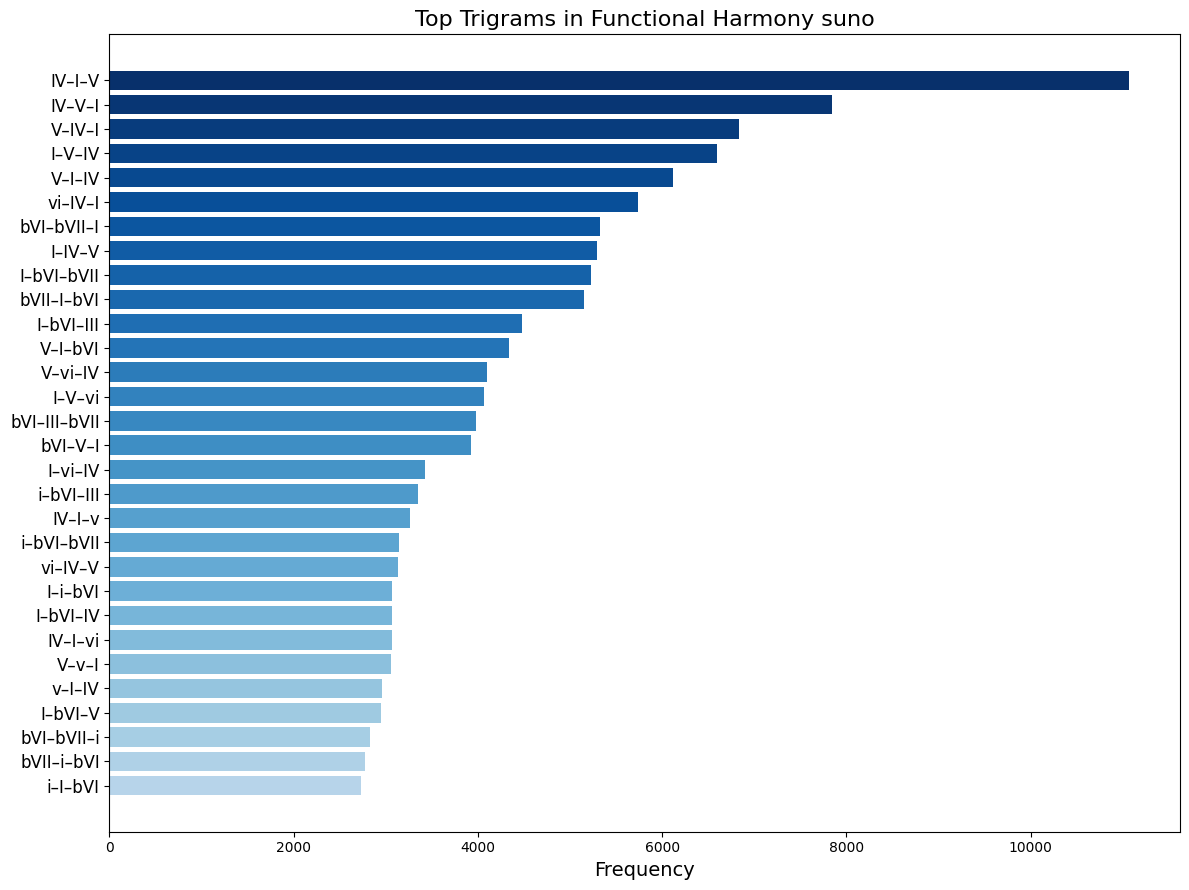

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get the trigrams and counts from your dictionary
trigrams = list(sorted_trigram_counts.keys())
counts = list(sorted_trigram_counts.values())

# How many to plot? (e.g., top 30)
top_n = 30
plot_trigrams = trigrams[:top_n]
plot_counts = counts[:top_n]

# Turn trigrams into readable strings
trigram_labels = ['–'.join(tri) for tri in plot_trigrams]

# Plot with blue color map
plt.figure(figsize=(12, 9))
bars = plt.barh(range(top_n), plot_counts[::-1], color=plt.cm.Blues(np.linspace(0.3, 1, top_n)))
plt.yticks(range(top_n), trigram_labels[::-1], fontsize=12)
plt.xlabel("Frequency", fontsize=14)
plt.title("Top Trigrams in Functional Harmony "+ collection, fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Define your collections and path
collections = ["lastfm", "suno", "udio"]
base_path = "/workspace/dataset"

# Gather all jsons per collection
all_jsons = {}
for col in collections:
    dataset_path = f"{base_path}/{col}"
    all_jsons[col] = load_files(dataset_path, 'normalized')

# Optional: Print counts
for col in collections:
    print(f"{col}: {len(all_jsons[col])} JSON files")


lastfm: 19853 JSON files
suno: 19972 JSON files
udio: 19992 JSON files


In [11]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def extract_trigrams(files):
    """Extract meaningful trigrams from a list of files"""
    trigrams = []
    for f in files:
        chord_dicts = get_JSON_files(f)
        chords = [functional_relabel(chord) for chord in chord_dicts]
        # Use the existing make_trigram function
        trigrams += make_trigram(chords)
    return trigrams

# Count trigrams per collection
trigram_counts = {}
for col in collections:
    trigrams = extract_trigrams(all_jsons[col])
    trigram_counts[col] = Counter(trigrams)

# Find top N trigrams across all collections
all_trigrams = set()
for c in trigram_counts.values():
    all_trigrams |= set([tr for tr, _ in c.most_common(10)])  # Fixed the syntax
all_trigrams = list(all_trigrams)

# Build barplot data
N = len(all_trigrams)
freqs = np.zeros((len(collections), N))
for j, col in enumerate(collections):
    for i, tri in enumerate(all_trigrams):
        freqs[j, i] = trigram_counts[col][tri]

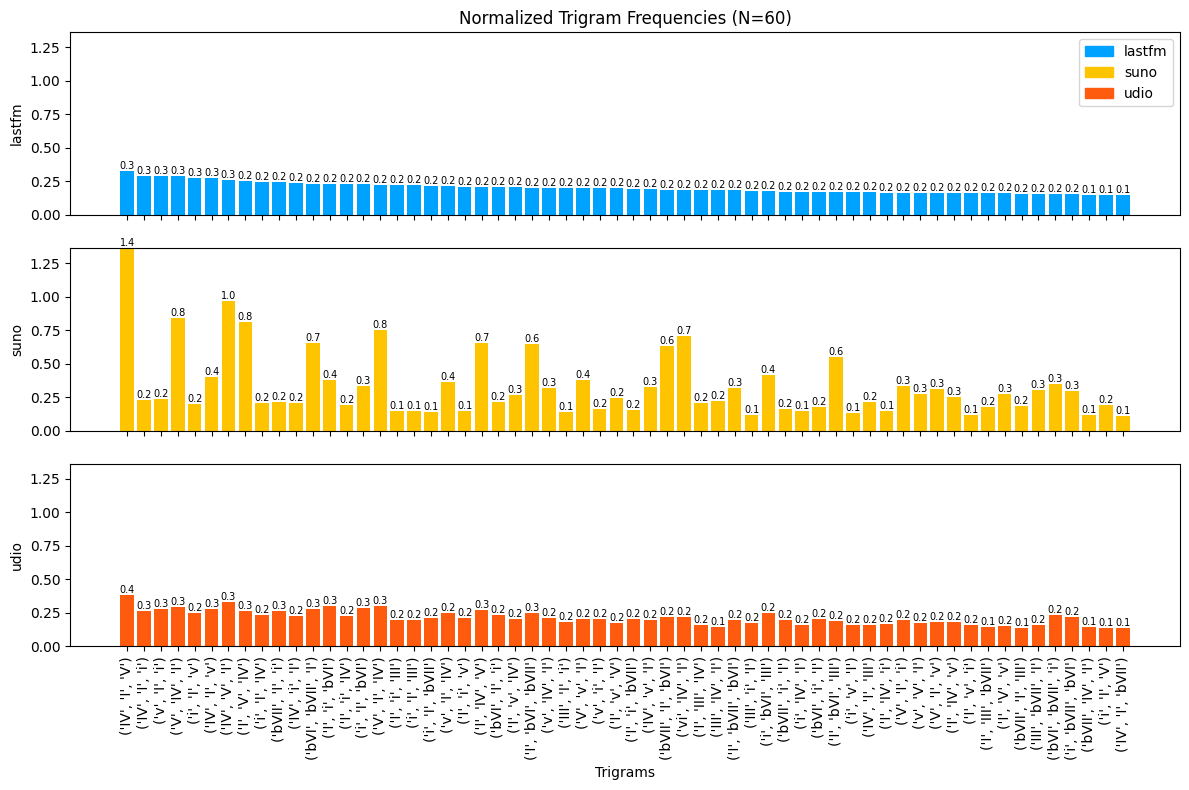

lastfm: 984,186 total trigrams
suno: 813,314 total trigrams
udio: 609,003 total trigrams


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Get most common trigrams from lastfm
N = 60
lastfm_trigrams = [tri for tri, _ in trigram_counts["lastfm"].most_common(N)]  # Fixed syntax

# Prepare data for each collection in this fixed order
freq_matrix = []
for col in collections:
    col_counts = []
    for tri in lastfm_trigrams:
        col_counts.append(trigram_counts[col][tri])
    freq_matrix.append(col_counts)

# Option 1: Normalize by total trigrams per collection (relative frequency)
# Calculate total trigrams per collection
total_trigrams = [sum(trigram_counts[col].values()) for col in collections]

# Normalize each row by its total
normalized_freq_matrix = []
for idx, col_counts in enumerate(freq_matrix):
    normalized_counts = [count / total_trigrams[idx] * 100 for count in col_counts]  # Convert to percentage
    normalized_freq_matrix.append(normalized_counts)

# Use normalized data
freq_matrix = normalized_freq_matrix
max_count = max([max(col_counts) for col_counts in freq_matrix])

colors = ["#00A2FF", "#FFC400", "#FF5B0E"]
legend_handles = [mpatches.Patch(color=colors[i], label=collections[i]) for i in range(3)]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for idx, col in enumerate(collections):
    axes[idx].bar(range(N), freq_matrix[idx], color=colors[idx])
    axes[idx].set_ylabel(f'{collections[idx]}')  # Changed to percentage
    axes[idx].set_ylim(0, max_count)
    
    if idx == 0:
        axes[idx].set_title(f"Normalized Trigram Frequencies (N={N})")  # Updated title
    
    # Add count labels on bars (show as percentage)
    for i, count in enumerate(freq_matrix[idx]):
        if count > 0.1:  # Only show if > 0.1%
            axes[idx].text(i, count, f'{count:.1f}', ha='center', va='bottom', fontsize=7)

# Set x-axis labels only on bottom plot
axes[-1].set_xticks(range(N))
axes[-1].set_xticklabels([str(tri) for tri in lastfm_trigrams], rotation=90)
axes[-1].set_xlabel("Trigrams")

# Add legend to top plot
axes[0].legend(
    handles=legend_handles,
    loc='upper right',
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

# Print normalization info
for idx, col in enumerate(collections):
    print(f"{col}: {total_trigrams[idx]:,} total trigrams")

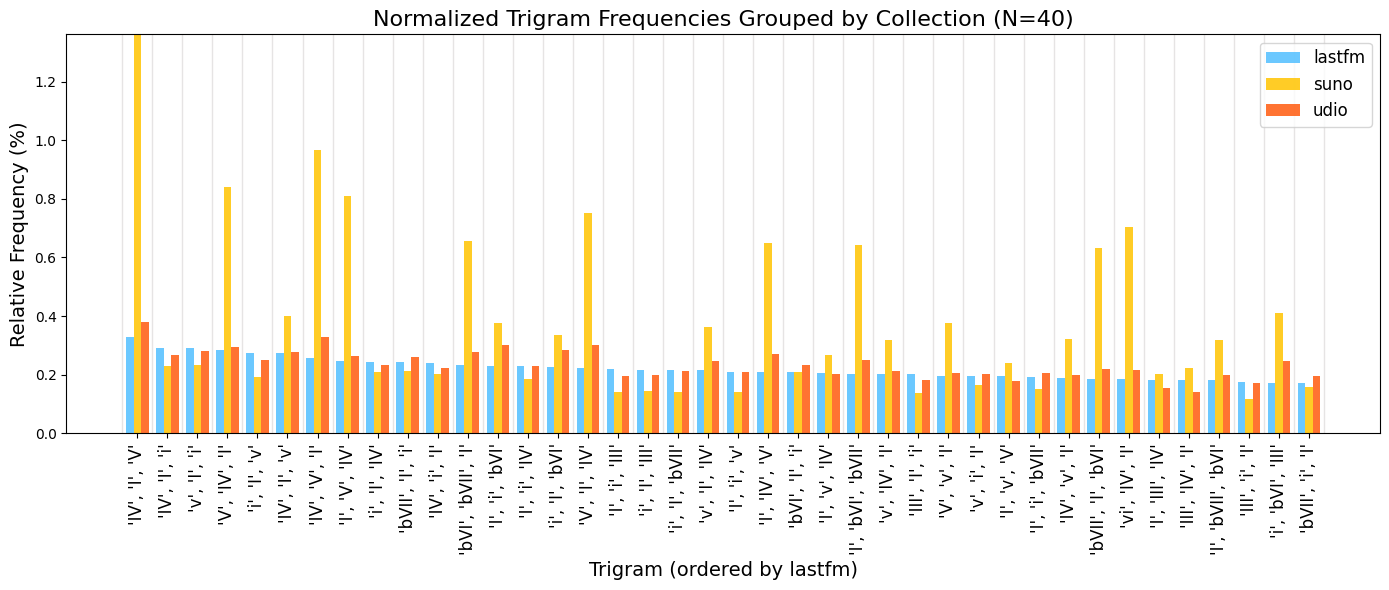

lastfm: 984,186 total trigrams
suno: 813,314 total trigrams
udio: 609,003 total trigrams


In [13]:
import matplotlib.pyplot as plt
import numpy as np

N = 40
lastfm_trigrams = [tri for tri, _ in trigram_counts["lastfm"].most_common(N)]  # Fixed syntax

freq_matrix = []
for col in collections:
   col_counts = []
   for tri in lastfm_trigrams:
       col_counts.append(trigram_counts[col][tri])
   freq_matrix.append(col_counts)

# Calculate total trigrams per collection for normalization
total_trigrams = [sum(trigram_counts[col].values()) for col in collections]

# Normalize each collection by its total (convert to percentage)
normalized_freq_matrix = []
for idx, col_counts in enumerate(freq_matrix):
   normalized_counts = [count / total_trigrams[idx] * 100 for count in col_counts]
   normalized_freq_matrix.append(normalized_counts)

# Use normalized data
freq_matrix = normalized_freq_matrix
max_count = max([max(col_counts) for col_counts in freq_matrix])

colors = ["#51BFFF", "#FFC400", "#FF5B0E"]

x = np.arange(N)
width = 0.25  # Adjusted width for better spacing

plt.figure(figsize=(14, 6))

for idx, (col, color) in enumerate(zip(collections, colors)):
   plt.bar(x + (idx - 1) * width, freq_matrix[idx], width=width, color=color, alpha=0.85, label=col)

# Add vertical gray dividers between trigrams
for i in range(N + 1):
   plt.axvline(i - 0.5, color="#E6E4E4", linestyle='-', linewidth=1, zorder=0)

plt.ylim(0, max_count)
plt.xticks(x, [str(tri).replace('(', '').replace(')', '') for tri in lastfm_trigrams], rotation=90, fontsize=12)
plt.xlabel("Trigram (ordered by lastfm)", fontsize=14)
plt.ylabel("Relative Frequency (%)", fontsize=14)
plt.title(f"Normalized Trigram Frequencies Grouped by Collection (N={N})", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print normalization info
for idx, col in enumerate(collections):
   print(f"{col}: {total_trigrams[idx]:,} total trigrams")

In [14]:
# song_id = "73f59cd4-1f73-4fa4-bb33-57836906938f"

# # audio_path = f"/workspace/samples/lastfm_samples/audio/{song_id}.mp3"
# audio_path = f"/mnt/Aimir_HD/suno/audio/{song_id}.mp3"
# print(audio_path)

# from IPython.display import Audio

# Audio(audio_path)



In [15]:
def clean_genre(raw):
    """Map genre strings to canonical form for analysis."""
    if raw is None:
        return None
    # Always lowercase and strip
    g = raw.strip().lower()
    # Genre mapping
    mapping = {
        'folkcountry': 'country',
        'country': 'country',
        'raphiphop': 'hip hop',
        'hip hop': 'hip hop',
        'rap': 'hip hop',
        'indie rock': 'alternative',
        'indie': 'alternative',
        'jazz': 'chill-out/jazz',  
        'funksoulrnb': 'soul/r&b',
        'blues': 'blues',
        'pop': 'pop',
        'rock': 'rock',
        'electronic': 'electronic',
        'metalcore': 'metal',
        'alternative': 'alternative',
        # Add more as needed
    }
    return mapping.get(g, g)  # default: return original, but cleaned


In [ ]:
import os
import json

collections = ["lastfm", "suno", "udio"]
base_path = "/workspace/dataset"

def extract_styles(style_json_path):
    with open(style_json_path, "r") as f:
        data = json.load(f)

    original = data.get("original", None)
    if isinstance(original, list):
        cleaned = [g.strip().lower() for g in original]
    elif isinstance(original, str):
        cleaned = [g.strip().lower() for g in original.split(",") if g.strip()]
    else:
        cleaned = []

    # Always get just the first genre as a string (or None)
    original_style = cleaned[0] if cleaned else None

    genres = data.get("genre_dortmund", {})
    sorted_genres = sorted(genres.items(), key=lambda x: float(x[1]), reverse=True)
    top_genre_1 = sorted_genres[0][0] if len(sorted_genres) > 0 else None
    top_genre_2 = sorted_genres[1][0] if len(sorted_genres) > 1 else None
    return clean_genre(original_style), clean_genre(top_genre_1), clean_genre(top_genre_2)

def is_valid_trigram(trigram):
    return len(set(trigram)) == 3  # All three chords must be different 

def extract_trigrams(harmony_json_path):
    if not os.path.exists(harmony_json_path):
        return []
    with open(harmony_json_path, "r") as f:
        try:
            data = json.load(f)
        except Exception as e:
            print(f"Problem loading {harmony_json_path}: {e}")
            return []
    # If data is a list of chords:
    if isinstance(data, list) and len(data) > 0 and "functional_harmony" in data[0]:
        chords = [functional_relabel(chord) for chord in data]
    elif isinstance(data, dict) and "chords" in data:
        chords = [functional_relabel(chord) for chord in data["chords"]]
    else:
        chords = []
    # Build trigrams with the filter:
    trigrams = []
    for i in range(len(chords) - 2):
        t = tuple(chords[i:i+3])
        if is_valid_trigram(t):
            trigrams.append(t)
    return trigrams

# Main data build loop
data_entries = []

for collection in collections:
    collection_path = os.path.join(base_path, collection)
    for song_id in os.listdir(collection_path):
        song_path = os.path.join(collection_path, song_id)
        style_json = os.path.join(song_path, f"{song_id}_style.json")
        harmony_json = os.path.join(song_path, f"{song_id}_normalized.json")
        if not os.path.exists(style_json):
            continue
        original_style, top_genre_1, top_genre_2 = extract_styles(style_json)
        trigrams = extract_trigrams(harmony_json)
        entry = {
            "collection": collection,
            "song_id": song_id,
            "original_style": original_style,
            "top_genre_1": top_genre_1,
            "top_genre_2": top_genre_2,
            "trigrams": trigrams,
        }
        data_entries.append(entry)

# Now data_entries has trigrams for each song!


In [17]:
import pandas as pd

df = pd.DataFrame(data_entries)

for col in ["original_style", "top_genre_1", "top_genre_2"]:
    print(f"\nTop 8 genres in '{col}':")
    for collection in df['collection'].unique():
        top_genres = (df[df['collection'] == collection][col]
                      .value_counts()
                      .head(8))
        print(f"{collection}: {top_genres.index.tolist()}")



Top 8 genres in 'original_style':
lastfm: ['alternative', 'rock', 'electronic', 'pop', 'metal', 'hip-hop', 'black metal', 'folk']
suno: ['pop', 'hip hop', 'rock', 'electronic', 'male vocals', 'female vocals', 'edm', 'country']
udio: ['male vocalist', 'female vocalist', 'electronic', 'rock', 'pop', 'hip hop', 'instrumental', 'chill-out/jazz']

Top 8 genres in 'top_genre_1':
lastfm: ['rock', 'electronic', 'chill-out/jazz', 'hip hop', 'country', 'pop', 'alternative', 'blues']
suno: ['rock', 'electronic', 'pop', 'chill-out/jazz', 'hip hop', 'country', 'soul/r&b', 'blues']
udio: ['rock', 'electronic', 'pop', 'hip hop', 'country', 'chill-out/jazz', 'blues', 'soul/r&b']

Top 8 genres in 'top_genre_2':
lastfm: ['electronic', 'alternative', 'chill-out/jazz', 'pop', 'rock', 'country', 'hip hop', 'blues']
suno: ['electronic', 'pop', 'chill-out/jazz', 'country', 'rock', 'hip hop', 'alternative', 'soul/r&b']
udio: ['electronic', 'pop', 'chill-out/jazz', 'country', 'hip hop', 'blues', 'rock', 'alte

In [18]:
import pandas as pd
from collections import Counter, defaultdict

from collections import Counter

top8_per_collection = {}

collections = ['lastfm', 'suno', 'udio']

for collection in collections:
    genre_list = [
        entry["original_style"]
        for entry in data_entries
        if entry["collection"] == collection and entry["original_style"] is not None
    ]
    counts = Counter(genre_list)
    most_common = counts.most_common(8)
    top8_per_collection[collection] = [genre for genre, _ in most_common]


# Find the union of top genres across all collections:
top_genres = set(
    [g for col in collections for g in top8_per_collection[col]]
)

# Build counters: {genre: {collection: Counter(trigram)}}
genre_coll_trigram_counts = defaultdict(lambda: defaultdict(Counter))

for entry in data_entries:
    genre = entry["original_style"]
    if genre not in top_genres:
        continue
    collection = entry["collection"]
    trigrams = entry.get("trigrams", [])  # Adjust as needed for your actual data
    genre_coll_trigram_counts[genre][collection].update(trigrams)

# For each genre, get top 20 trigrams (by total frequency across collections)
all_data = []
for genre in top_genres:
    trigram_set = set()
    # Union of trigrams in all collections for this genre
    for collection in collections:
        trigram_set.update(genre_coll_trigram_counts[genre][collection].keys())
    # Compute total frequency per trigram (across collections)
    trigram_total_counts = Counter()
    for collection in collections:
        trigram_total_counts.update(genre_coll_trigram_counts[genre][collection])
    # Select top 20
    top_20_trigrams = [t for t, _ in trigram_total_counts.most_common(20)]
    # Gather frequencies for plotting
    for trigram in top_20_trigrams:
        row = {"genre": genre, "trigram": " - ".join(trigram)}
        for collection in collections:
            row[collection] = genre_coll_trigram_counts[genre][collection][trigram]
        all_data.append(row)

df_plot = pd.DataFrame(all_data)


In [19]:
from collections import Counter, defaultdict
import pandas as pd

collections = ['lastfm', 'suno', 'udio']

source = "top_genre_1" # original_style, top_genre_1, top_genre_2

# Step 1: Get list of genres (top 8 or so) you want to plot
genre_counts = Counter(entry[source] for entry in data_entries if entry[source])
top_genres = [g for g, _ in genre_counts.most_common(8)]  # Adjust N as needed

# Step 2: Aggregate trigrams per (genre, collection)
trigram_counts = defaultdict(lambda: defaultdict(Counter))  # genre -> collection -> trigram -> count

for entry in data_entries:
    genre = entry[source]
    if genre not in top_genres:
        continue
    collection = entry['collection']
    for trigram in entry['trigrams']:
        trigram_counts[genre][collection][trigram] += 1


In [20]:
# Build long-format data for plotting
all_rows = []

for genre in top_genres:
    # Union of top 20 trigrams across all collections for this genre
    all_trigrams = Counter()
    for collection in collections:
        all_trigrams += trigram_counts[genre][collection]
    top20_trigrams = [t for t, _ in all_trigrams.most_common(20)]
    # Gather data
    for trigram in top20_trigrams:
        trigram_str = " - ".join(trigram)
        for collection in collections:
            count = trigram_counts[genre][collection][trigram]
            all_rows.append({
                "genre": genre,
                "trigram": trigram_str,
                "collection": collection,
                "count": count
            })

df_long = pd.DataFrame(all_rows)


/tmp/ipykernel_2053583/3951338008.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/3951338008.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/3951338008.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/3951338008.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)


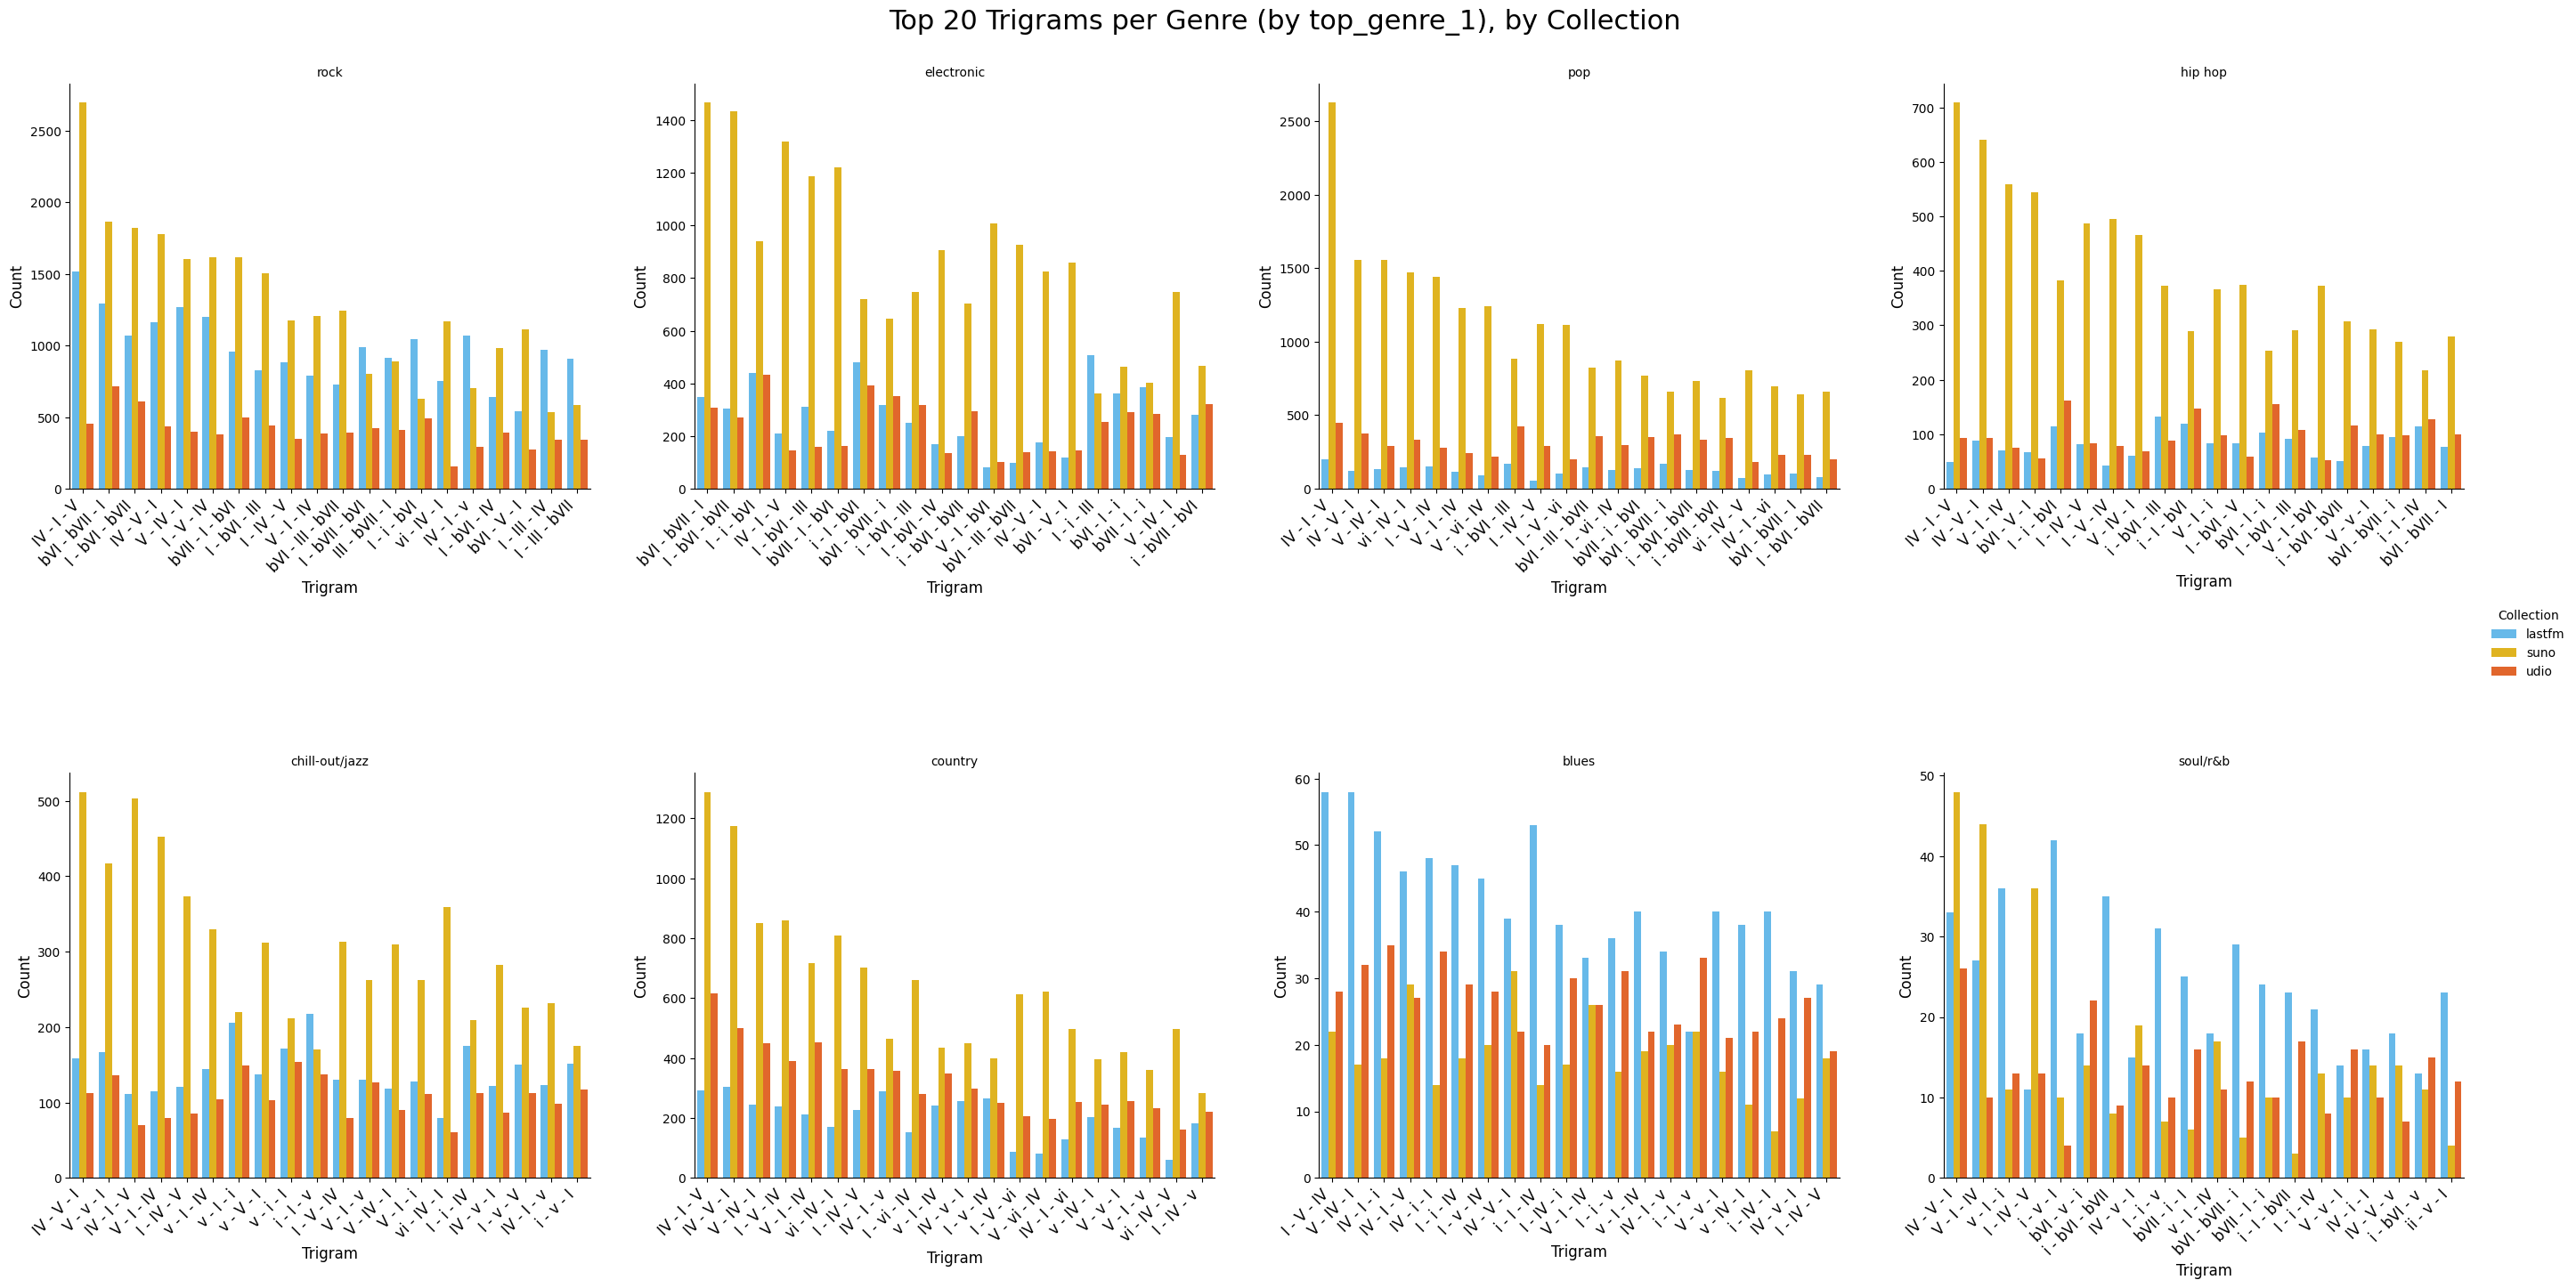

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ["#51BFFF", "#FFC400", "#FF5B0E"]  # lastfm, suno, udio
collection_order = ['lastfm', 'suno', 'udio']
palette = dict(zip(collection_order, colors))

g = sns.FacetGrid(
    df_long, 
    col="genre", 
    col_wrap=4,      # fewer columns, bigger plots
    height=7,        # much bigger facets
    sharex=False, 
    sharey=False
)
g.map_dataframe(
    sns.barplot, 
    x="trigram", 
    y="count", 
    hue="collection", 
    palette=palette,
    hue_order=collection_order
)
g.set_titles("{col_name}", fontsize=16)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    ax.set_xlabel("Trigram", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
g.add_legend(title="Collection")
plt.subplots_adjust(top=0.92, hspace=0.7, wspace=0.2)
plt.suptitle("Top 20 Trigrams per Genre (by top_genre_1), by Collection", fontsize=22)
plt.show()


/tmp/ipykernel_2053583/992260500.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2053583/992260500.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2053583/992260500.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2053583/992260500.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2053583/992260500.py:32: UserWarning: set

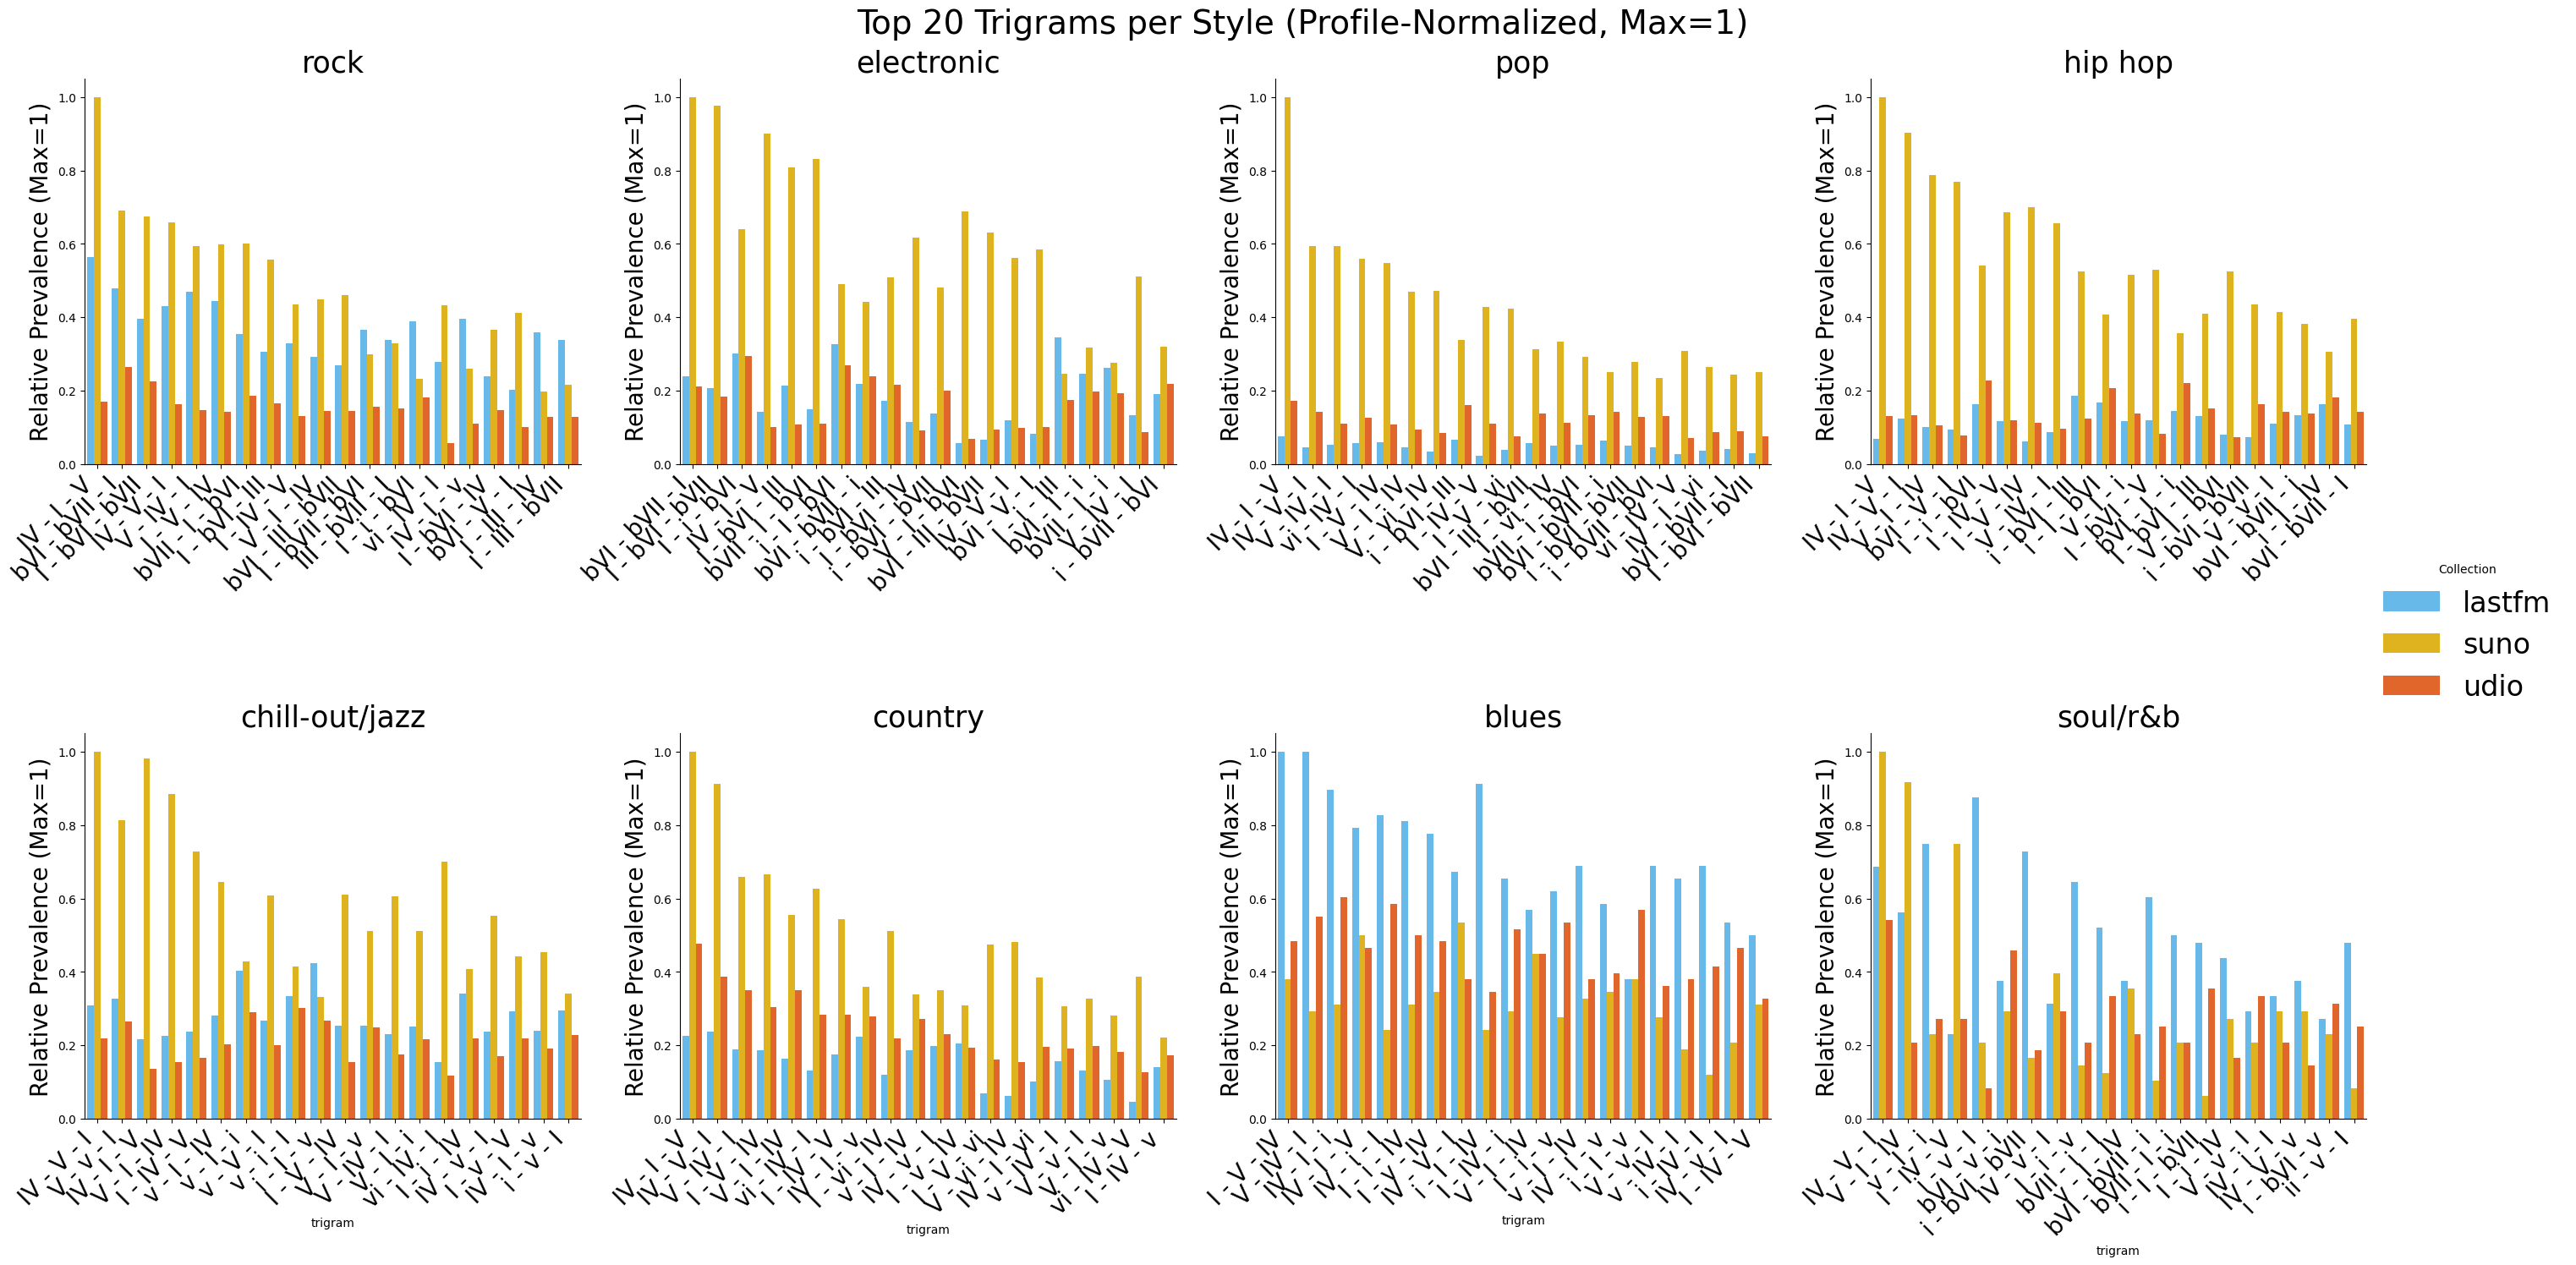

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute the maximum trigram count PER genre (across all collections for that genre)
df_long['max_count_per_genre'] = df_long.groupby('genre')['count'].transform('max')

# Step 2: Normalize all counts to that maximum, so Y-axis is 0..1
df_long['profile_ratio'] = df_long['count'] / df_long['max_count_per_genre']

font_size = 20
title_font_size = 25
# Step 3: Plot with the normalized value as y
g = sns.FacetGrid(
    df_long, 
    col="genre", 
    col_wrap=4,      # fewer columns, bigger plots
    height=7,        # much bigger facets
    sharex=False, 
    sharey=False
)
g.map_dataframe(
    sns.barplot, 
    x="trigram", 
    y="profile_ratio", 
    hue="collection", 
    palette=palette,
    hue_order=collection_order
)
g.set_titles("{col_name}", fontsize=title_font_size, size=title_font_size)
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45, labelsize=font_size)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel("Relative Prevalence (Max=1)", fontsize=font_size)
g.add_legend(title="Collection", fontsize=24, title_fontsize=20)
plt.subplots_adjust(top=0.92, hspace=0.7, wspace=0.2)
plt.suptitle("Top 20 Trigrams per Style (Profile-Normalized, Max=1)", fontsize=28)
plt.show()


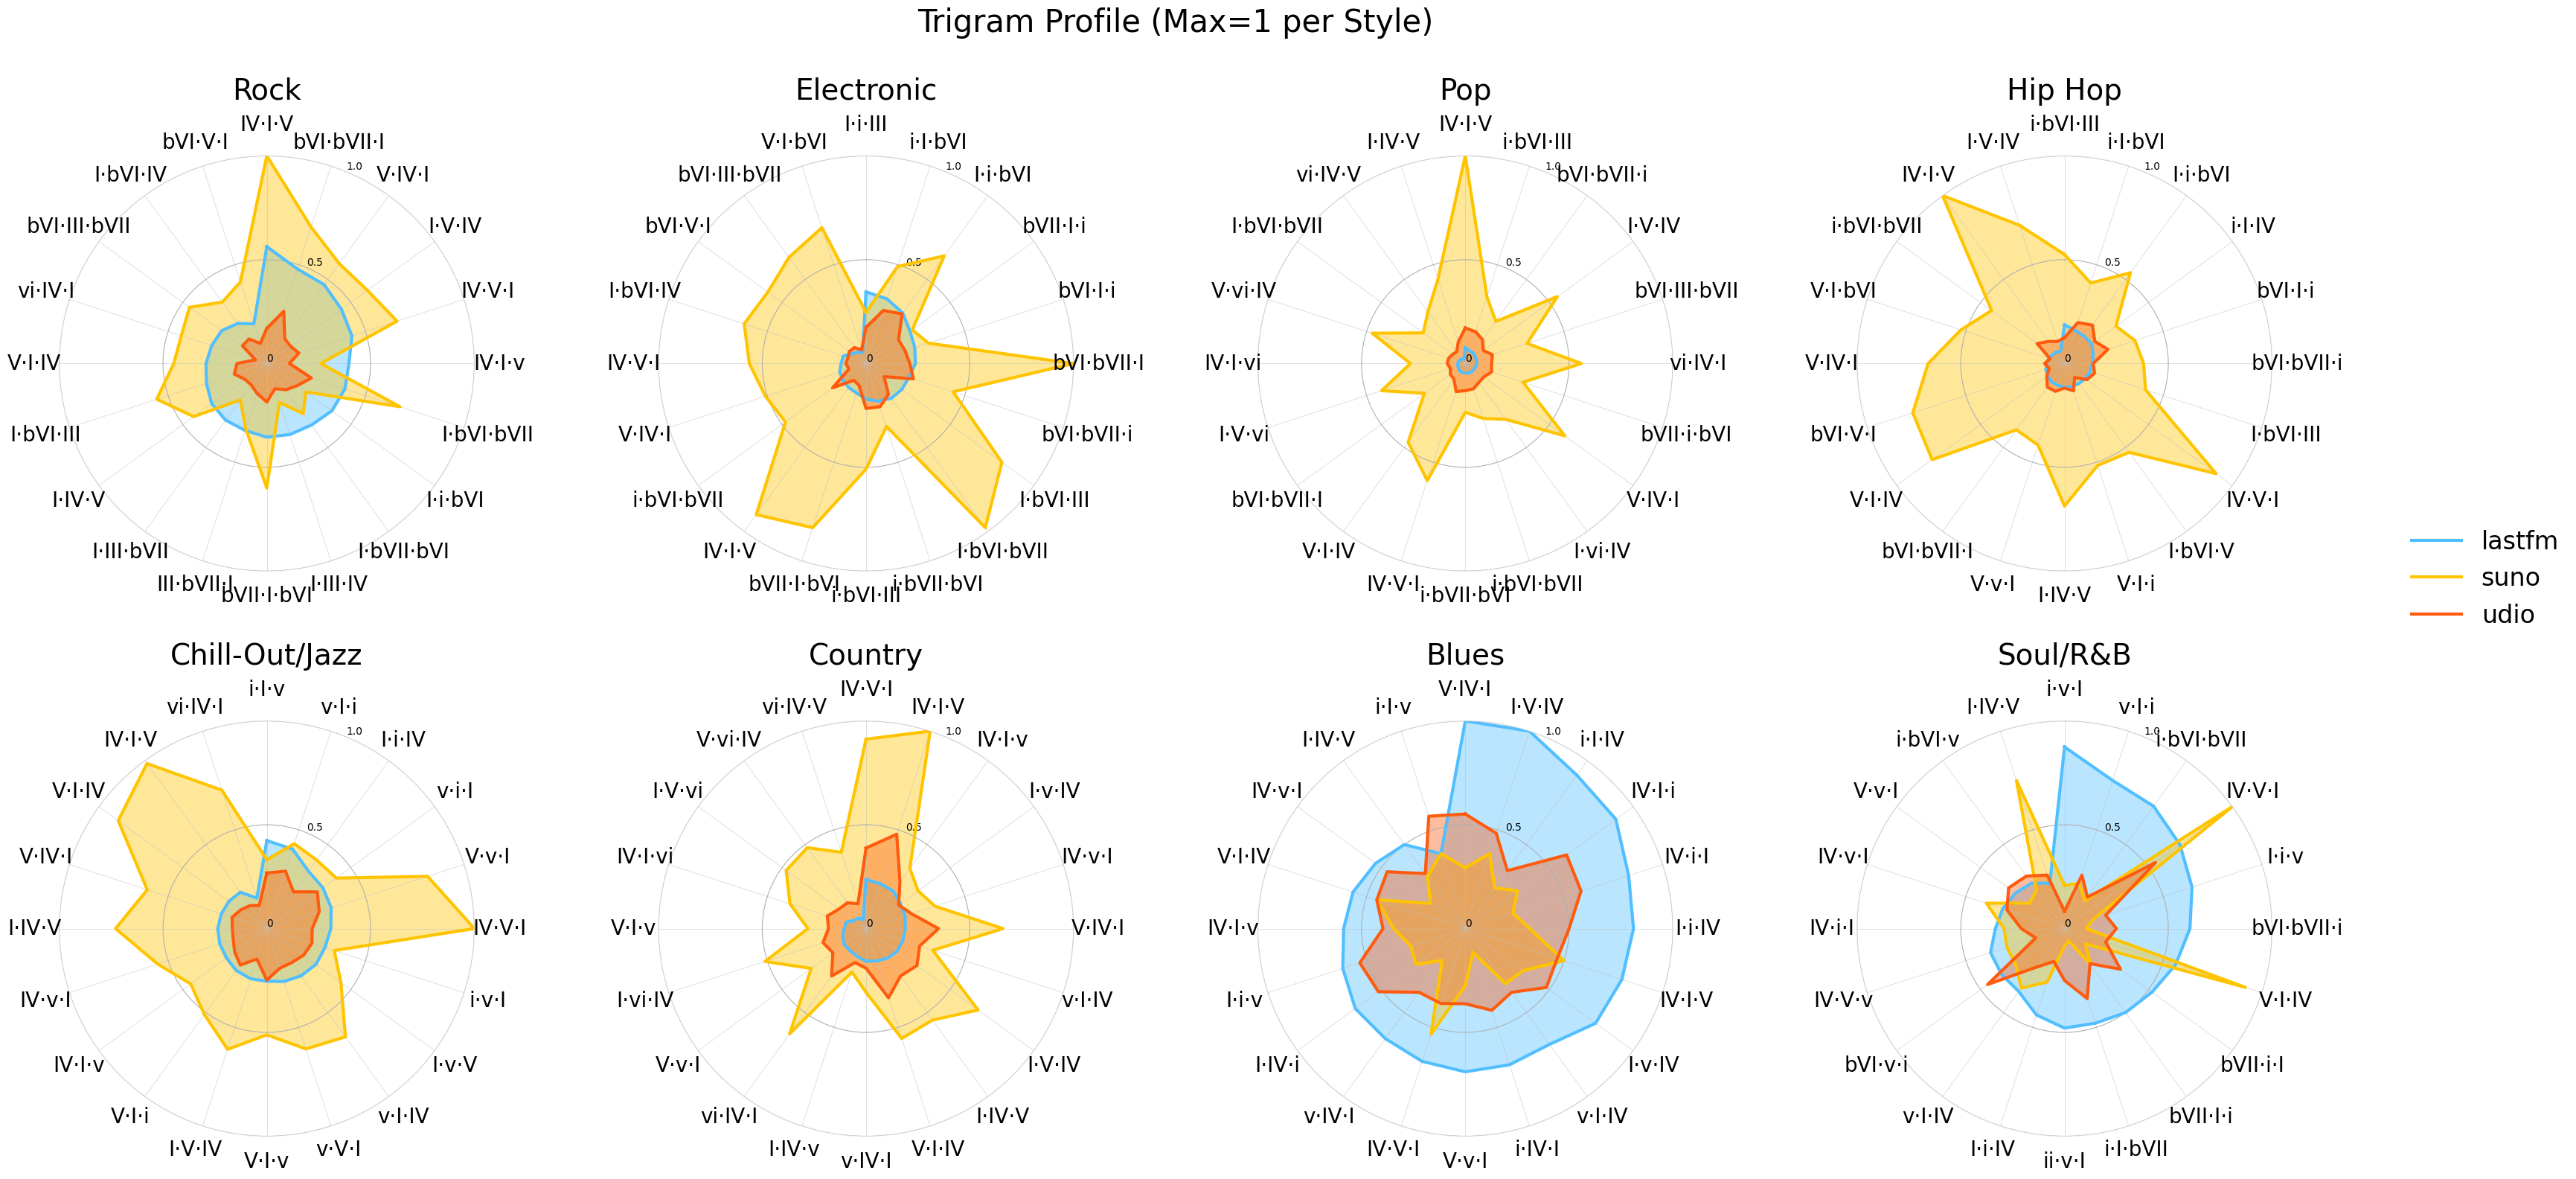

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

collections = ['lastfm', 'suno', 'udio']
colors = ["#51BFFF", "#FFC400", "#FF5B0E"]
N = 20 # number of trigrams
genres = df_long['genre'].unique()
n_genres = len(genres)
n_cols = 4
n_rows = int(np.ceil(n_genres / n_cols))

fig, axes = plt.subplots(
   nrows=n_rows, ncols=n_cols, figsize=(n_cols * 8, n_rows * 8),
   subplot_kw=dict(polar=True)
)
axes = axes.flatten()

# 1. Get trigram order per genre based on lastfm (reference)
reference_collection = "lastfm"
trigram_order_per_genre = {
   genre: (
       df_long[
           (df_long['genre'] == genre) & (df_long['collection'] == reference_collection)
       ]
       .groupby('trigram')['count']
       .sum()
       .sort_values(ascending=False)
       .head(N)
       .index.tolist()
   )
   for genre in genres
}

for ax_idx, genre in enumerate(genres):
   top_trigrams = trigram_order_per_genre[genre]
   num_vars = len(top_trigrams)
   angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
   angles += angles[:1] # Close the loop
   
   axes[ax_idx].set_theta_offset(np.pi / 2) # Rotate by 90 degrees (π/2 radians)
   axes[ax_idx].set_theta_direction(-1)
   axes[ax_idx].spines['polar'].set_color("#D5D5D5")
   axes[ax_idx].spines['polar'].set_linewidth(1.0)
   axes[ax_idx].spines['polar'].set_alpha(0.5)
   
   for col, color in zip(collections, colors):
       subset = df_long[(df_long["genre"] == genre) & (df_long["collection"] == col)]
       subset = subset.set_index("trigram")
       data = [subset.loc[t, "profile_ratio"] if t in subset.index else 0 for t in top_trigrams]
       data += data[:1]
       axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=3)
       axes[ax_idx].fill(angles, data, color=color, alpha=0.4)
   
   # Set category labels with special positioning for first trigram only
   axes[ax_idx].set_xticks(angles[:-1])
   axes[ax_idx].set_xticklabels([])  # Clear default labels
   
   # Manually position labels
   for i, (angle, trigram) in enumerate(zip(angles[:-1], top_trigrams)):
       # Move only the first trigram (index 0) further out
       if i == 0:
           label_radius = 1.15  # More separation for first trigram
       else:
           label_radius = 1.12  # Normal separation for others
       
       axes[ax_idx].text(
           angle, label_radius, str(trigram).replace(' - ', '·'),
           horizontalalignment='center', verticalalignment='center',
           fontsize=20, transform=axes[ax_idx].transData
       )
   
   axes[ax_idx].set_yticks([0, 0.5, 1.0])
   axes[ax_idx].set_yticklabels(['0', '0.5', '1.0'])
   axes[ax_idx].set_ylim(0, 1)
   axes[ax_idx].xaxis.grid(True, color="#BFBFBF", linewidth=0.5, alpha=0.7)
   # Increase title padding even more to avoid overlap with first trigram
   axes[ax_idx].set_title(f"{genre.title()}", fontsize=28, pad=55)

# Remove any unused axes
for ax in axes[len(genres):]:
   fig.delaxes(ax)

plt.suptitle("Trigram Profile (Max=1 per Style)", fontsize=30)
# Increase both horizontal and vertical spacing between subplots
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=5.0, w_pad=3.5)

line_handles = [
   mlines.Line2D([], [], color=color, linewidth=3, label=col)
   for col, color in zip(collections, colors)
]
fig.legend(
   handles=line_handles,
   labels=collections,
   loc='center left',
   bbox_to_anchor=(1.01, 0.5),
   fontsize=24,
   frameon=False
)
plt.show()

/tmp/ipykernel_2053583/4144715697.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/4144715697.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/4144715697.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/4144715697.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_2053583/4144715697.py:39: UserWarning: set_ti

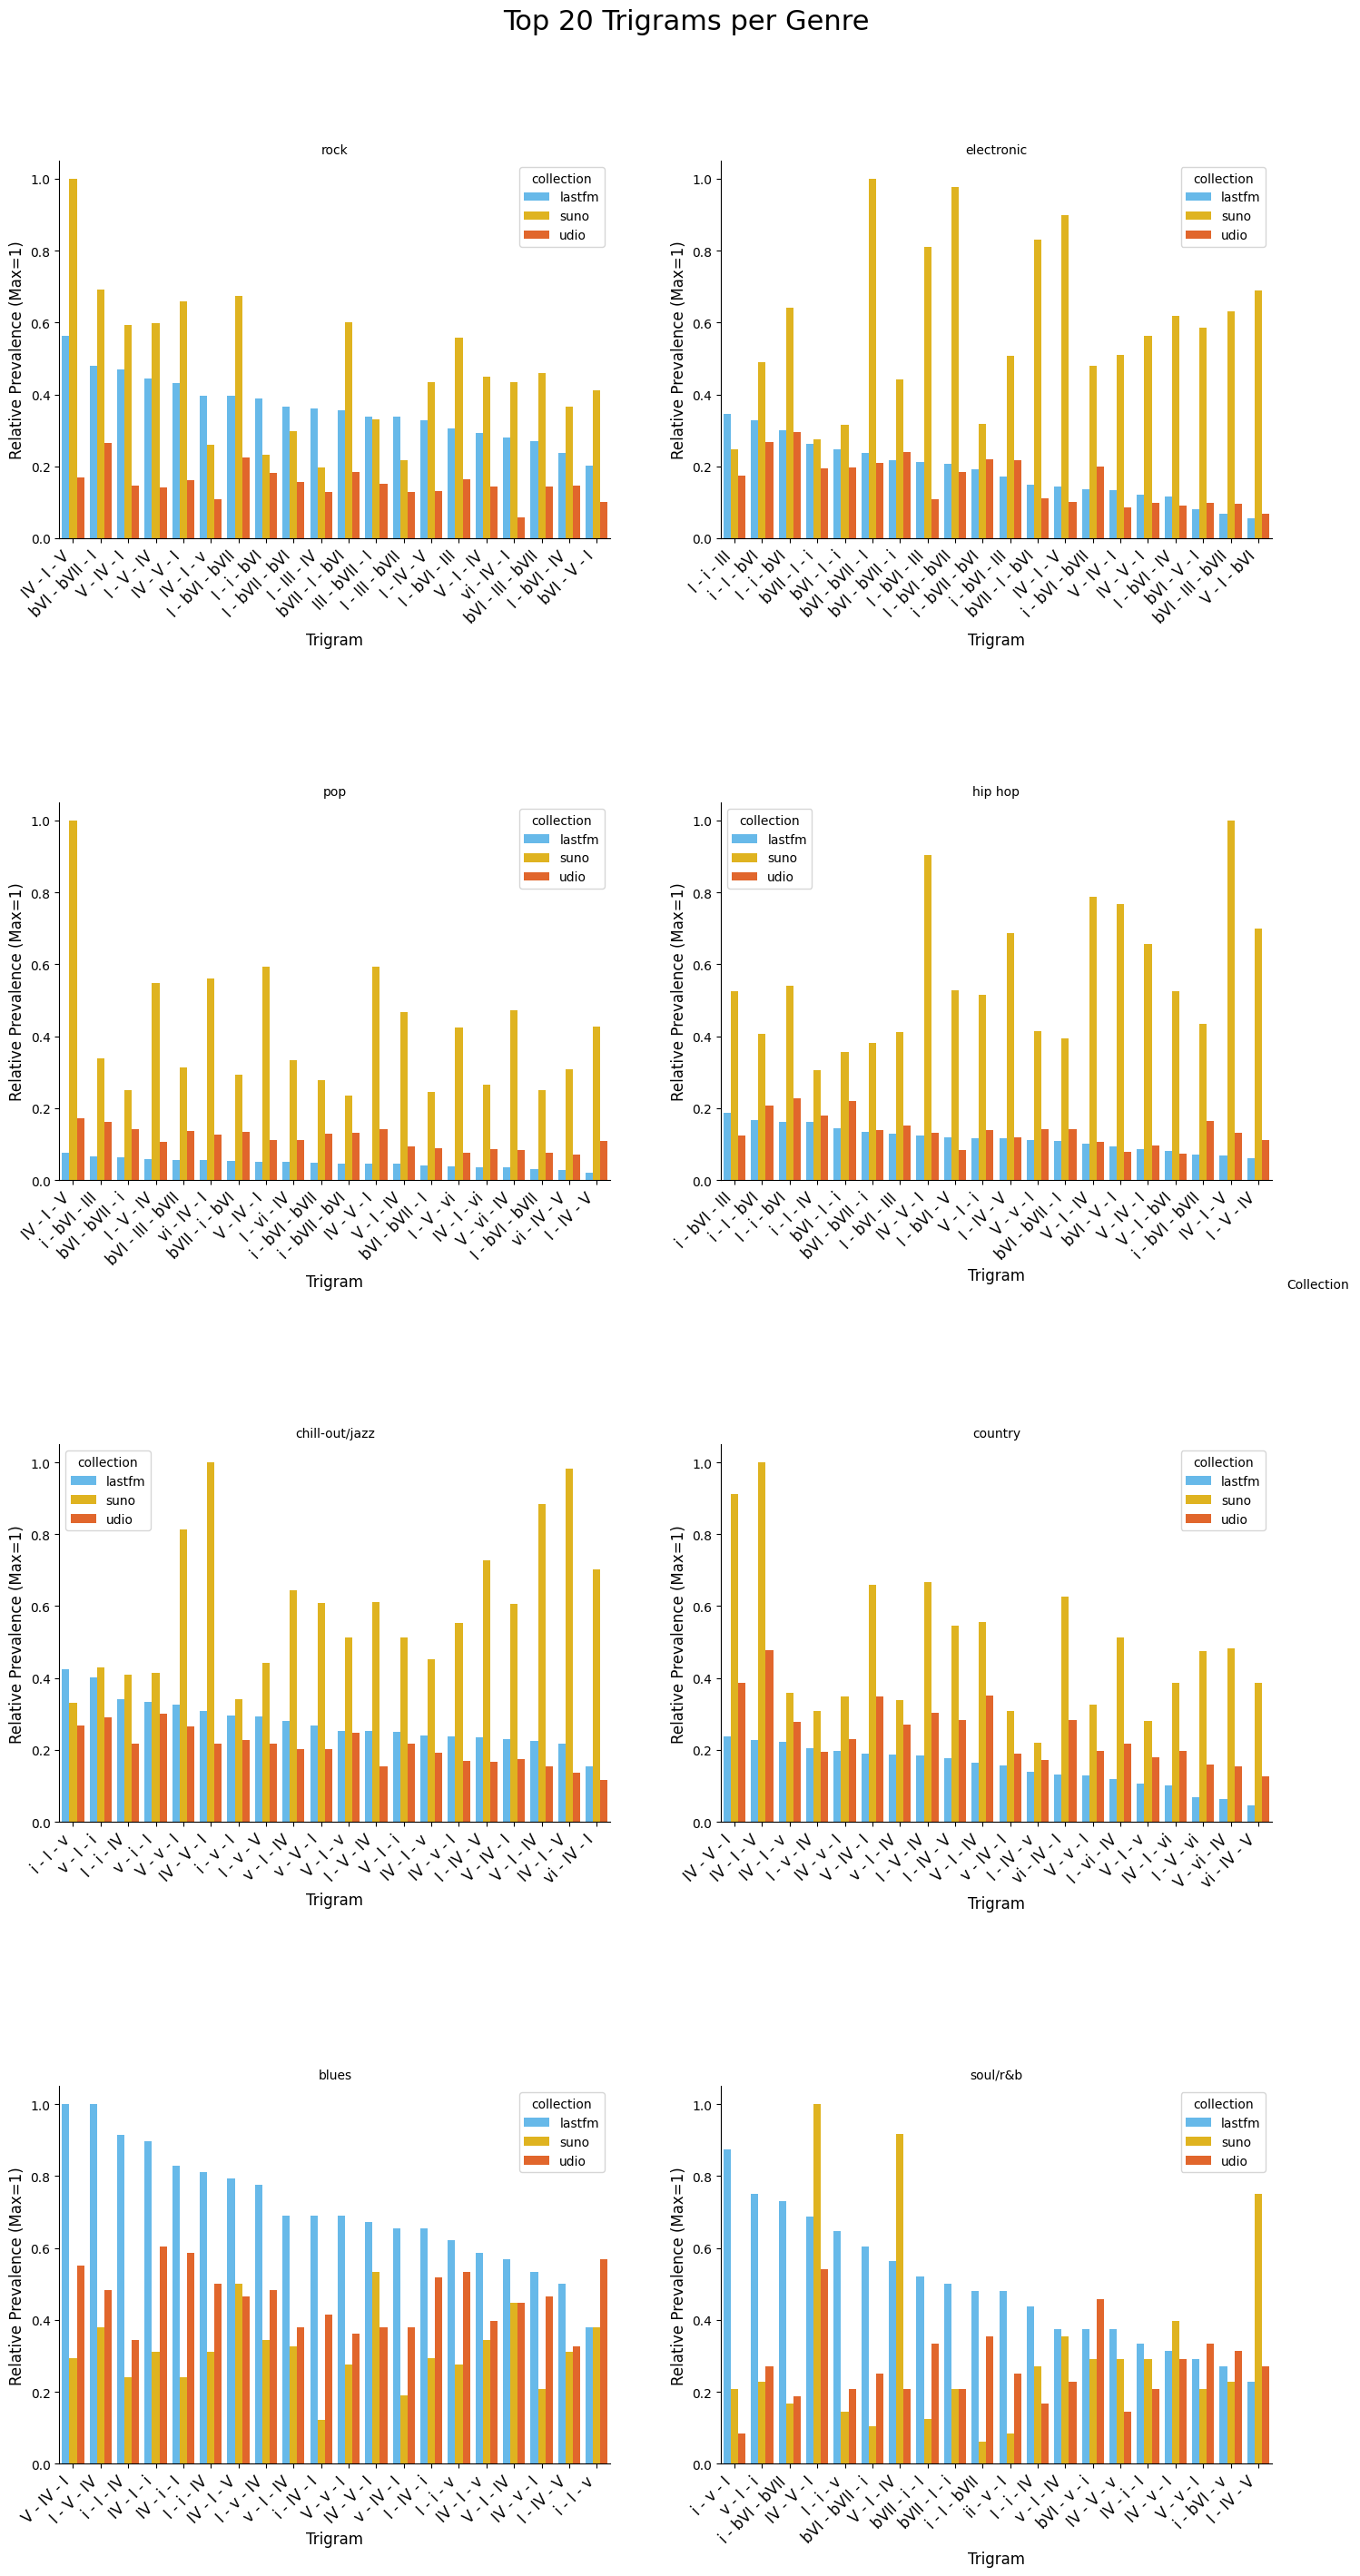

In [24]:
# For each genre, get lastfm's top 20 trigrams (by count)
N = 20
reference_collection = 'lastfm'

trigram_order_per_genre = {
    genre: (
        df_long[
            (df_long['genre'] == genre) & (df_long['collection'] == reference_collection)
        ]
        .groupby('trigram')['count']
        .sum()
        .sort_values(ascending=False)
        .head(N)
        .index.tolist()
    )
    for genre in df_long['genre'].unique()
}
g = sns.FacetGrid(
    df_long, 
    col="genre", 
    col_wrap=2,
    height=7,
    sharex=False, 
    sharey=False
)
for ax, genre in zip(g.axes.flatten(), df_long['genre'].unique()):
    order = trigram_order_per_genre[genre]
    data = df_long[df_long['genre'] == genre]
    sns.barplot(
        data=data,
        x="trigram",
        y="profile_ratio",
        hue="collection",
        palette=palette,
        hue_order=collection_order,
        order=order,
        ax=ax
    )
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=12)
    ax.set_xlabel("Trigram", fontsize=12)
    ax.set_ylabel("Relative Prevalence (Max=1)", fontsize=12)

g.set_titles("{col_name}", fontsize=16)
g.add_legend(title="Collection")
plt.subplots_adjust(top=0.92, hspace=0.7, wspace=0.2)
plt.suptitle("Top 20 Trigrams per Genre", fontsize=22)
plt.show()


In [25]:
# Print the 20 most common trigrams independently per collections using df_long

for collection in collections:
    print(f"\nTop 20 Trigrams in {collection}:")
    top_trigrams = (
        df_long[df_long['collection'] == collection]
        .groupby('trigram')['count']
        .sum()
        .sort_values(ascending=False)
        .head(50)
    )
    for trigram, count in top_trigrams.items():
        print(f"{trigram}: {count}")



Top 20 Trigrams in lastfm:
IV - I - V: 2423
IV - V - I: 2081
V - IV - I: 2078
I - V - IV: 1823
bVI - bVII - I: 1822
I - i - bVI: 1602
IV - I - v: 1513
I - bVI - bVII: 1450
I - IV - V: 1411
V - I - IV: 1364
I - bVI - III: 1229
bVII - I - bVI: 1176
vi - IV - I: 1149
I - bVII - bVI: 988
bVI - III - bVII: 971
I - III - IV: 970
III - bVII - I: 914
I - III - bVII: 910
I - bVI - IV: 812
bVI - V - I: 729
bVI - bVII - i: 610
i - I - bVI: 599
i - bVI - III: 555
I - i - III: 506
V - v - I: 467
bVI - I - i: 465
v - I - IV: 443
IV - v - I: 423
i - bVI - bVII: 415
bVII - I - i: 409
i - bVII - bVI: 401
I - v - IV: 309
I - vi - IV: 283
V - I - v: 266
I - i - IV: 243
v - I - i: 242
v - IV - I: 241
i - I - v: 239
IV - I - vi: 225
V - I - i: 211
i - v - I: 193
I - V - vi: 189
I - IV - v: 181
v - i - I: 171
V - vi - IV: 171
i - I - IV: 168
I - v - V: 150
V - I - bVI: 139
bVII - i - bVI: 139
v - V - I: 137

Top 20 Trigrams in suno:
IV - I - V: 9173
IV - V - I: 6569
V - IV - I: 5553
I - V - IV: 4746
bVI - 

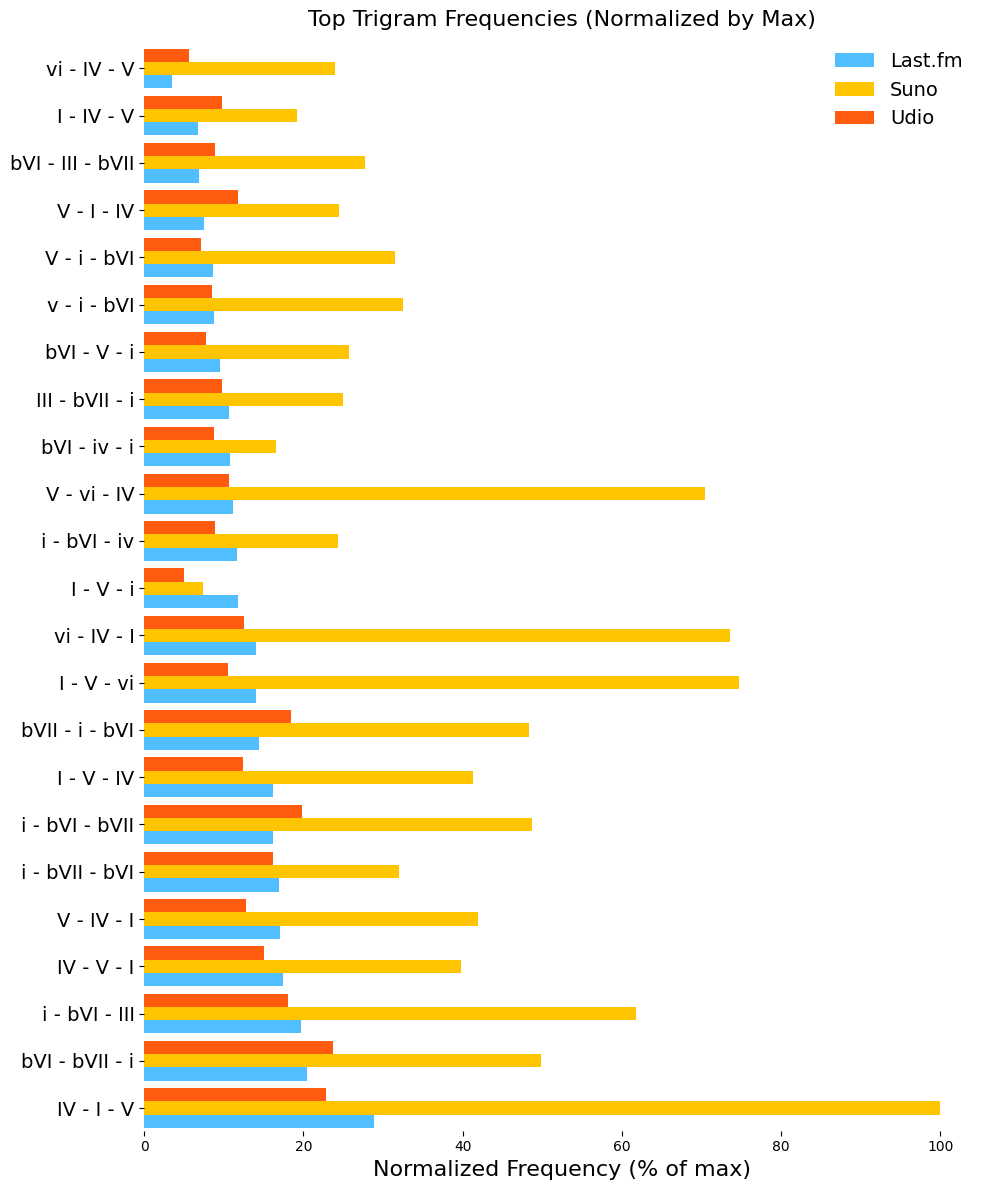

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Put your data here
data = [
    ["IV - I - V",      5253, 18204, 4150],
    ["bVI - bVII - i",  3724, 9063,  4322],
    ["i - bVI - III",   3587, 11256, 3291],
    ["IV - V - I",      3170, 7248,  2734],
    ["V - IV - I",      3102, 7642,  2336],
    ["i - bVII - bVI",  3089, 5825,  2943],
    ["i - bVI - bVII",  2953, 8869,  3617],
    ["I - V - IV",      2953, 7525,  2263],
    ["bVII - i - bVI",  2629, 8811,  3368],
    ["I - V - vi",      2563, 13595, 1918],
    ["vi - IV - I",     2545, 13393, 2273],
    ["I - V - i",       2149, 1339,  912],
    ["i - bVI - iv",    2115, 4435,  1621],
    ["V - vi - IV",     2037, 12832, 1930],
    ["bVI - iv - i",    1964, 3003,  1598],
    ["III - bVII - i",  1932, 4546,  1782],
    ["bVI - V - i",     1744, 4678,  1406],
    ["v - i - bVI",     1599, 5909,  1541],
    ["V - i - bVI",     1572, 5745,  1303],
    ["V - I - IV",      1356, 4445,  2137],
    ["bVI - III - bVII",1243, 5059,  1609],
    ["I - IV - V",      1234, 3487,  1772],
    ["vi - IV - V",     637,  4362,  1034],
]

collections = ['Last.fm', 'Suno', 'Udio']

df = pd.DataFrame(data, columns=["Trigram"] + collections)
df.set_index("Trigram", inplace=True)

# Normalize all values to the maximum in the whole table
max_val = df.values.max()
df_norm = df / max_val * 100  # for percentage

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
bar_width = 0.28
y = np.arange(len(df))

colors = ["#51BFFF", "#FFC400", "#FF5B0E"]  # You can adjust

for i, collection in enumerate(collections):
    ax.barh(y + bar_width*i, df_norm[collection], height=bar_width, label=collection, color=colors[i])

ax.set_yticks(y + bar_width)
ax.set_yticklabels(df.index, fontsize=14)
ax.invert_yaxis()  # Most frequent at top
ax.set_xlabel('Normalized Frequency (% of max)', fontsize=16)
ax.legend(fontsize=14, frameon=False)
ax.set_title('Top Trigram Frequencies (Normalized by Max)', fontsize=16)

for spine in ax.spines.values():
    spine.set_linewidth(0)
    spine.set_color('#dddddd')
    
# Reduce white space at top and bottom
ax.set_ylim(-0.2, len(df))
plt.tight_layout()
plt.show()


In [27]:
# count how many files are inside ireal_songs dataset
import os
def count_files_in_directory(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

# Example usage
directory_path = '/workspace/dataset/triad_references'
file_count = count_files_in_directory(directory_path)
print(f"Total files in '{directory_path}': {file_count}")

Total files in '/workspace/dataset/triad_references': 83


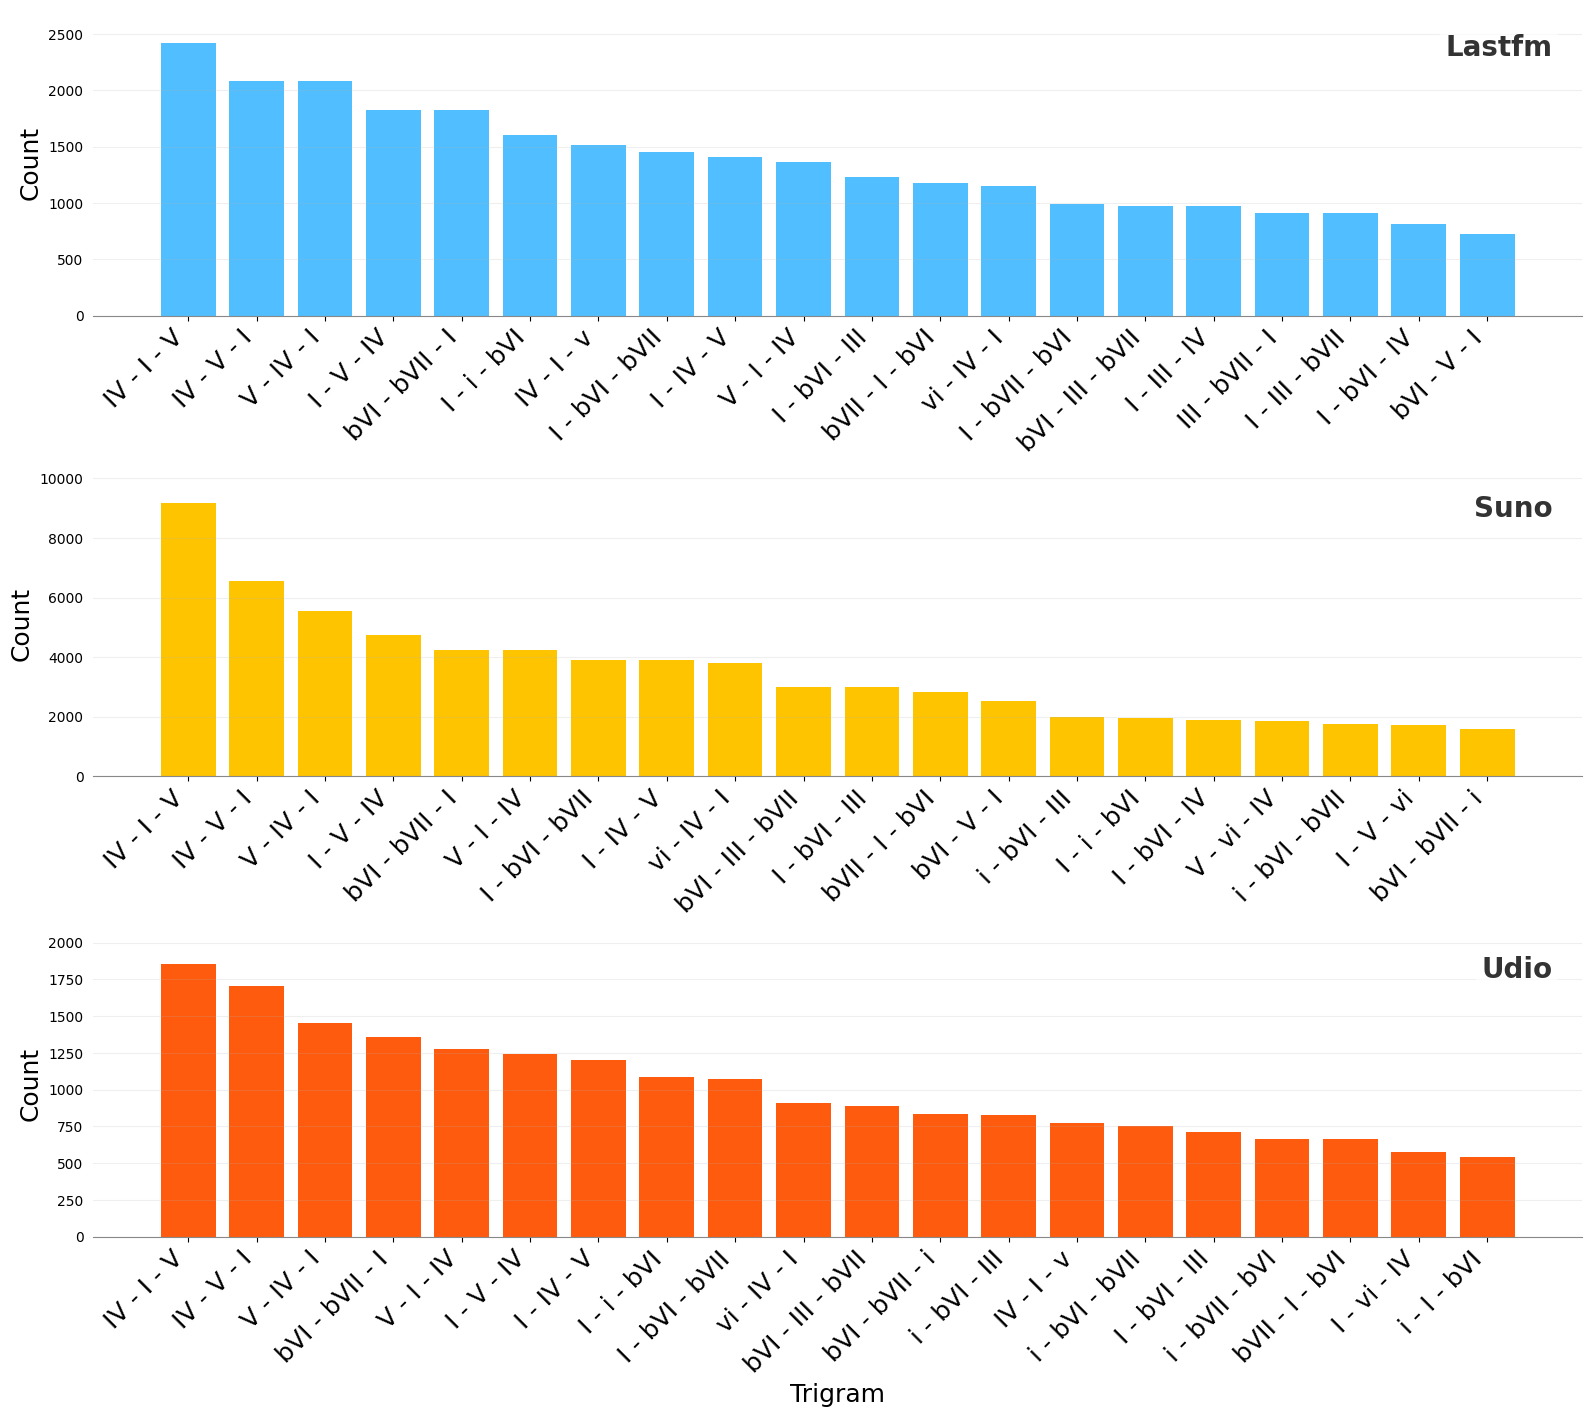

In [28]:
import matplotlib.pyplot as plt

color_map = {
    "lastfm": "#51BFFF",
    "suno": "#FFC400",
    "udio": "#FF5B0E"
}

collections = ['lastfm', 'suno', 'udio']

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=False)
text_size = 18

for i, collection in enumerate(collections):
    ax = axes[i]
    # Aggregate counts per trigram!
    top_trigrams = (
        df_long[df_long['collection'] == collection]
        .groupby('trigram')['count'].sum()
        .sort_values(ascending=False)
        .head(20)
    )
    bars = ax.bar(
        range(len(top_trigrams)),
        top_trigrams.values,
        color=color_map[collection]
    )
    ax.set_xticks(range(len(top_trigrams)))
    ax.set_xticklabels(
        [' - '.join(t) if isinstance(t, (tuple, list)) else t for t in top_trigrams.index],
        rotation=45, ha='right', fontsize=text_size
    )
    ax.set_title("", fontsize=text_size)
    ax.set_ylabel("Count", fontsize=text_size)
    ax.grid(axis='y', alpha=0.2)
    ax.margins(y=0.12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['bottom'].set_color("#888888")
    ax.yaxis.set_ticks_position('none')
    ax.text(
        0.98, 0.92,
        collection.capitalize(),
        color='#333333',
        fontsize=20, fontweight='bold',
        ha='right', va='top',
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.2", edgecolor='none', facecolor='white', alpha=0.7)
    )

axes[-1].set_xlabel("Trigram", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.98], pad=1.0)
plt.show()


In [29]:
most_common_suno_trigram = (
    df_long[df_long['collection'] == 'suno']
    .sort_values('count', ascending=False)
    .iloc[0]['trigram']
)
print("Most common Suno trigram:", most_common_suno_trigram)


Most common Suno trigram: IV - I - V


In [30]:
from trigram_search import query_trigram_usage

most_common_suno_trigram = (
    df_long[df_long['collection'] == 'suno']
    .sort_values('count', ascending=False)
    .iloc[0]['trigram']
)
# Format for function call:
if isinstance(most_common_suno_trigram, (tuple, list)):
    trigram_query = most_common_suno_trigram
else:
    trigram_query = str(most_common_suno_trigram)

df_styles = query_trigram_usage(trigram_query)
print(df_styles)


{'functional_trigrams': {'count': 343, 'styles': [['Jazz', 153], ['Pop', 80], ['Ballad', 64], ['Rock', 46], ['Blues', 39], ['Samba', 37], ['Gospel', 31], ['Waltz', 23], ['Bossa', 9], ['Latin', 8]], 'matched': 'partial (2/3)', 'function': ['I', 'V', 'I']}, 'trigram_dataset': {'total_count': 0, 'styles': [], 'composers': []}}


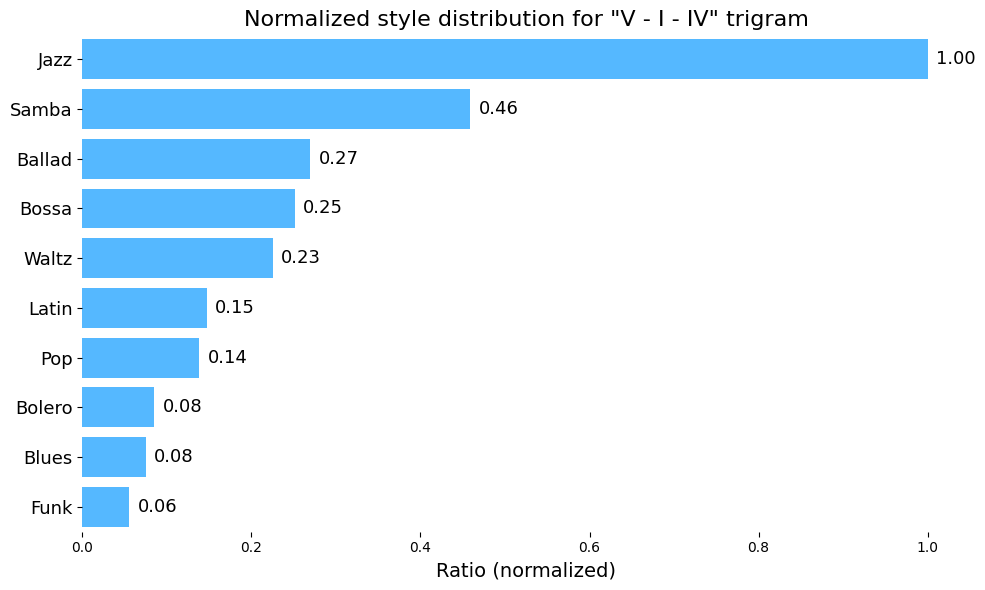

In [31]:
import matplotlib.pyplot as plt
from trigram_search import query_trigram_usage

# Choose the N-th most common trigram (0=most, 1=second, etc.)
most = 5

# Find the most common Suno trigrams by total (summed) count
top_suno_trigrams = (
    df_long[df_long['collection'] == 'suno']
    .groupby('trigram')['count']
    .sum()
    .sort_values(ascending=False)
)

trigram_query = top_suno_trigrams.index[most]

result = query_trigram_usage(trigram_query)
styles_counts = result["functional_trigrams"]["styles"]

labels, counts = zip(*styles_counts)
labels = [l.capitalize() for l in labels]  # Capitalize for plot
counts = list(counts)
max_count = max(counts)
norm_counts = [c / max_count for c in counts]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels[::-1], norm_counts[::-1], color="#55b8ff", edgecolor="none")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_ylim(-0.5, len(labels) - 0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}", va='center', fontsize=13)

ax.set_xlabel("Ratio (normalized)", fontsize=14)
trigram_str = ' - '.join(trigram_query) if isinstance(trigram_query, (list, tuple)) else str(trigram_query)
ax.set_title(f'Normalized style distribution for \"{trigram_str}\" trigram', fontsize=16)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()


Querying trigram: IV - V - I
Query result: {'count': 2045, 'styles': [['rock', 4354], ['pop', 2736], ['metal', 893], ['folk', 634], ['indie', 586], ['punk', 564], ['electronic', 445], ['country', 352], ['ambient', 287], ['dance', 119]], 'genres': [['rock', 857.1292275266994], ['folkcountry', 223.41488840141082], ['pop', 192.2924670199199], ['electronic', 181.92015985669093], ['jazz', 174.9858901670317], ['alternative', 169.24217430420072], ['blues', 92.04349970573982], ['raphiphop', 77.77071550099589], ['funksoulrnb', 76.18048358423005]], 'matched': 'partial (2/3)', 'function': ['I', 'V', 'IV'], 'song_ids': [['5f56dda85323708b72ba4c9df9dbc8e6', 15], ['31e71f69db2067a6d89a466f209056f4', 13], ['102964d38d604e8a5ab95dea0a8f080e', 13], ['6fb7cc3602f556cfed80f3c13f3fa8e5', 12], ['2d4d6cbf965a874b874d8e6f8685a8ea', 12], ['ba4b66266769a6327c6b1af5f543e83a', 11], ['cc430393733de2d6a36bb3fc1f31a553', 11], ['b6ae4a5405df11be3018b9aea52ddb7f', 11], ['11a5fa0866704ee12db7ce0854fc9aa9', 10], ['17f2

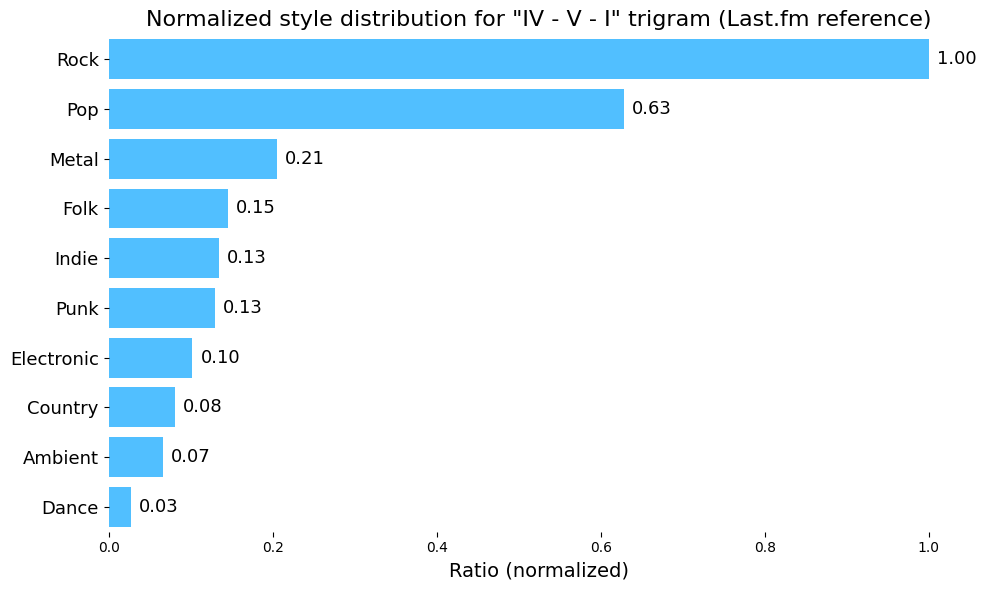

In [32]:
from trigram_search_lastfm import query_lastfm_trigram_usage
# --- Choose which common trigram you want (0 = most common, 1 = 2nd, etc.)
trigram_rank = 1

# Get all Suno trigrams, aggregate by sum, and sort by total count
top_suno_trigrams = (
    df_long[df_long['collection'] == 'suno']
    .groupby('trigram')['count']
    .sum()
    .sort_values(ascending=False)
)

# Get the trigram itself (this is a tuple of function names)
trigram_query = top_suno_trigrams.index[trigram_rank]

print("Querying trigram:", trigram_query)
result = query_lastfm_trigram_usage(trigram_query)
print("Query result:", result)

styles_counts = result["styles"]
labels, counts = zip(*styles_counts)
labels, counts = list(labels), list(counts)
labels = [l.capitalize() for l in labels]

max_count = max(counts)
norm_counts = [c / max_count for c in counts]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels[::-1], norm_counts[::-1], color="#51BFFF", edgecolor="none")  # Last.fm blue

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_ylim(-0.5, len(labels) - 0.5)

for bar in bars:
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va='center',
        fontsize=13
    )

ax.set_xlabel("Ratio (normalized)", fontsize=14)
trigram_str = (
    ' - '.join(trigram_query)
    if isinstance(trigram_query, (list, tuple))
    else str(trigram_query)
)
ax.set_title(
    f'Normalized style distribution for \"{trigram_str}\" trigram (Last.fm reference)',
    fontsize=16
)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()